In [1]:
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import chain
from sklearn.linear_model import LinearRegression
import os
import logging

In [2]:
from utils.OutlierUtils import remove_outliers_by_region
from utils.OutlierUtils import sanitize_response_name
from utils.OutlierUtils import left_derivatives
from utils.OutlierUtils import merge_close_points
from utils.OutlierUtils import get_region

In [3]:
# This cell is tagged with 'parameters'
output_path = './output/'
path_to_data = './data/Sample A_Pt-Stds-070325_modified_july_9th.csv'

In [4]:
response_index = 1 # Change this to select the response column

In [5]:
# Import data
df = pd.read_csv(path_to_data)
t = df['Time']
df

,Replicate,Reading,Time,ArCl -/75(Pulse/CPS),Pt -/195(Pulse/CPS)
0,1,1,0.000,3160.349535,370.004792
1,1,2,0.150,3660.468906,400.005600
2,1,3,0.301,3120.340741,450.007088
3,1,4,0.451,3420.409423,380.005054
4,1,5,0.601,2960.306688,310.003363
...,...,...,...,...,...
3480,1,3481,523.399,2880.290333,41740.891610
3481,1,3482,523.549,2660.247669,40266.669300
3482,1,3483,523.699,3400.404648,41018.804560
3483,1,3484,523.850,3180.353973,39835.462920


In [6]:
# set the response data
if not df.columns.empty:
    cols_to_drop = []
    if 'Time' in df.columns:
        cols_to_drop.append('Time')
    if 'Replicate' in df.columns:
        cols_to_drop.append('Replicate')
    if 'Reading' in df.columns:
        cols_to_drop.append('Reading')

    responses = df.drop(columns=cols_to_drop)
    if responses.empty and not df.empty: # Check if all columns were dropped, and df wasn't empty initially
        raise ValueError("All columns were identified as non-response columns. No response data left.")
else:
    raise ValueError("DataFrame has no columns.")

response = responses.columns[response_index-1]
response_data = df[response]

In [7]:
# creat output folder
os.makedirs(f'{output_path}', exist_ok=True)

#create dataset path
dataset_name = path_to_data.split('/')[-1].split('.')[0]
dataset_path = f'{output_path}/{dataset_name}'

os.makedirs(dataset_path, exist_ok=True)

In [8]:
safe_name = sanitize_response_name(response)
figure_dir = f'{dataset_path}/figures/{safe_name}'
os.makedirs(figure_dir, exist_ok=True)

In [9]:
# Identifying shifts with k-means
X = collections.deque(t)
Y = collections.deque(response_data)

In [10]:
# Normalize time
df['Time'] = df['Time'] - df['Time'].min()
df

,Replicate,Reading,Time,ArCl -/75(Pulse/CPS),Pt -/195(Pulse/CPS)
0,1,1,0.000,3160.349535,370.004792
1,1,2,0.150,3660.468906,400.005600
2,1,3,0.301,3120.340741,450.007088
3,1,4,0.451,3420.409423,380.005054
4,1,5,0.601,2960.306688,310.003363
...,...,...,...,...,...
3480,1,3481,523.399,2880.290333,41740.891610
3481,1,3482,523.549,2660.247669,40266.669300
3482,1,3483,523.699,3400.404648,41018.804560
3483,1,3484,523.850,3180.353973,39835.462920


In [11]:
%matplotlib qt

clicked_coordinates = None # Variable to store the click location
left_derivatives_df_c = left_derivatives(df['Time'].to_numpy(), df[response].to_numpy())


def onclick(event):
    global clicked_coordinates # Declare it global to modify the outside variable
    if event.xdata is not None and event.ydata is not None:
        clicked_coordinates = (event.xdata, event.ydata)
        print(f"Clicked at data coordinates: x={event.xdata}, y={event.ydata}")
        plt.close(fig) # Close the window

    else:
        print("Click was outside the plot area.")

fig, ax1 = plt.subplots(figsize=(18, 12), layout='constrained') # Increased figure size for clarity
plt.scatter(df['Time'], df[response])

# Save derivative and data pllot
plt.savefig(f'{output_path}/{dataset_name}/Derivative-Data-Plot', bbox_inches='tight',dpi=300)

cid = fig.canvas.mpl_connect('button_press_event', onclick)

# Now your loop can run while the plot is interactive
print("Waiting for a click...")
start_time = time.time()
timeout_seconds = 1000 # Your desired timeout

while True:
    if clicked_coordinates:
        print(f"Click detected at: {clicked_coordinates}")
        break
    if (time.time() - start_time) > timeout_seconds:
        print('Timed out. No click detected within the specified time.')
        break
    plt.pause(0.1) # Process GUI events for a short period
                   # This is crucial for interactive mode to work
plt.ioff() # Turn off interactive mode
plt.show() # Keep the plot open until manually closed after the loop

Waiting for a click...
Clicked at data coordinates: x=166.05125948716682, y=3283.614599962759
Click detected at: (np.float64(166.05125948716682), np.float64(3283.614599962759))


In [12]:
%matplotlib inline

# After the window is closed, you can access the stored coordinates
if clicked_coordinates:
    logging.info(f"The final stored coordinates are: {clicked_coordinates}")
else:
    logging.info("No valid click was registered before the window closed.")

first_region = (np.array([0]).astype(float)[0], clicked_coordinates[0])
first_region

INFO: The final stored coordinates are: (np.float64(166.05125948716682), np.float64(3283.614599962759))


(np.float64(0.0), np.float64(166.05125948716682))

In [13]:
# Get left derivatives
left_derivatieves_df_c = left_derivatives_df_c[left_derivatives_df_c['Time'] > first_region[1]]
left_derivatives_df_c.set_index(['Time'], inplace=True)
left_derivatives_df_c

,Y,Left_Derivative
Time,,
0.000,3160.349535,NaN
0.150,3660.468906,3334.129140
0.301,3120.340741,-3577.007715
0.451,3420.409423,2000.457880
0.601,2960.306688,-3067.351567
...,...,...
523.399,2880.290333,-2517.097185
523.549,2660.247669,-1466.951093
523.699,3400.404648,4934.379860


In [14]:
# Define the first region
mask1 = (left_derivatives_df_c['Left_Derivative'] > left_derivatives_df_c['Y'])
shifts = left_derivatives_df_c[mask1]
mask2 = (shifts.index > first_region[1])
shifts = shifts[mask2]

shifts


,Y,Left_Derivative
Time,,
166.645,3340.390492,3867.492333
167.698,3640.463795,4000.935367
167.999,3320.385829,5299.096325
168.600,3700.479212,4934.483493
170.255,3400.404648,3709.419364
...,...,...
520.391,3460.419057,3576.957629
522.195,3440.414226,5201.110380
522.647,3240.367458,3576.902543


In [16]:
def get_detected_intervals(shifts_index: list):
    result = [first_region]
    for i in range(1,len(shifts_index)-1):
        start_p = shifts_index[i]
        next_p = shifts_index[i+1]
        result.append((start_p, next_p))
    return result

detected_intervals = get_detected_intervals(shifts_index=shifts.index)
detected_intervals.append((detected_intervals[-1][1], df['Time'].max()))
detected_intervals


[(np.float64(0.0), np.float64(166.05125948716682)),
 (np.float64(167.698), np.float64(167.999)),
 (np.float64(167.999), np.float64(168.6)),
 (np.float64(168.6), np.float64(170.255)),
 (np.float64(170.255), np.float64(170.556)),
 (np.float64(170.556), np.float64(172.511)),
 (np.float64(172.511), np.float64(172.812)),
 (np.float64(172.812), np.float64(173.714)),
 (np.float64(173.714), np.float64(174.767)),
 (np.float64(174.767), np.float64(176.12)),
 (np.float64(176.12), np.float64(177.324)),
 (np.float64(177.324), np.float64(182.287)),
 (np.float64(182.287), np.float64(182.738)),
 (np.float64(182.738), np.float64(183.189)),
 (np.float64(183.189), np.float64(183.791)),
 (np.float64(183.791), np.float64(192.364)),
 (np.float64(192.364), np.float64(192.665)),
 (np.float64(192.665), np.float64(194.77)),
 (np.float64(194.77), np.float64(195.823)),
 (np.float64(195.823), np.float64(199.132)),
 (np.float64(199.132), np.float64(200.937)),
 (np.float64(200.937), np.float64(201.839)),
 (np.float6

# Adjust p here

In [18]:
p = 90

In [19]:
merged_points = merge_close_points(df=df, regions=detected_intervals, p=p, response=response)
merged_points_list = sorted(list(set(tuple(chain.from_iterable(merged_points)))))
merged_points

INFO: (np.float64(0.0), np.float64(166.05125948716682))
INFO: get_region called with t0=0.0, tf=166.05125948716682. Filtered DataFrame shape: (1105, 5)
INFO:       Replicate  Reading     Time  ArCl -/75(Pulse/CPS)  Pt -/195(Pulse/CPS)
0             1        1    0.000           3160.349535           370.004792
1             1        2    0.150           3660.468906           400.005600
2             1        3    0.301           3120.340741           450.007088
3             1        4    0.451           3420.409423           380.005054
4             1        5    0.601           2960.306688           310.003363
...         ...      ...      ...                   ...                  ...
1100          1     1101  165.442           3420.409423           310.003363
1101          1     1102  165.592           3700.479212           400.005600
1102          1     1103  165.743           3000.315033           410.005884
1103          1     1104  165.893           2820.278361           520.00

[(np.float64(0.0), np.float64(166.05125948716682))]

In [20]:
shifts

,Y,Left_Derivative
Time,,
166.645,3340.390492,3867.492333
167.698,3640.463795,4000.935367
167.999,3320.385829,5299.096325
168.600,3700.479212,4934.483493
170.255,3400.404648,3709.419364
...,...,...
520.391,3460.419057,3576.957629
522.195,3440.414226,5201.110380
522.647,3240.367458,3576.902543


## Final Plot

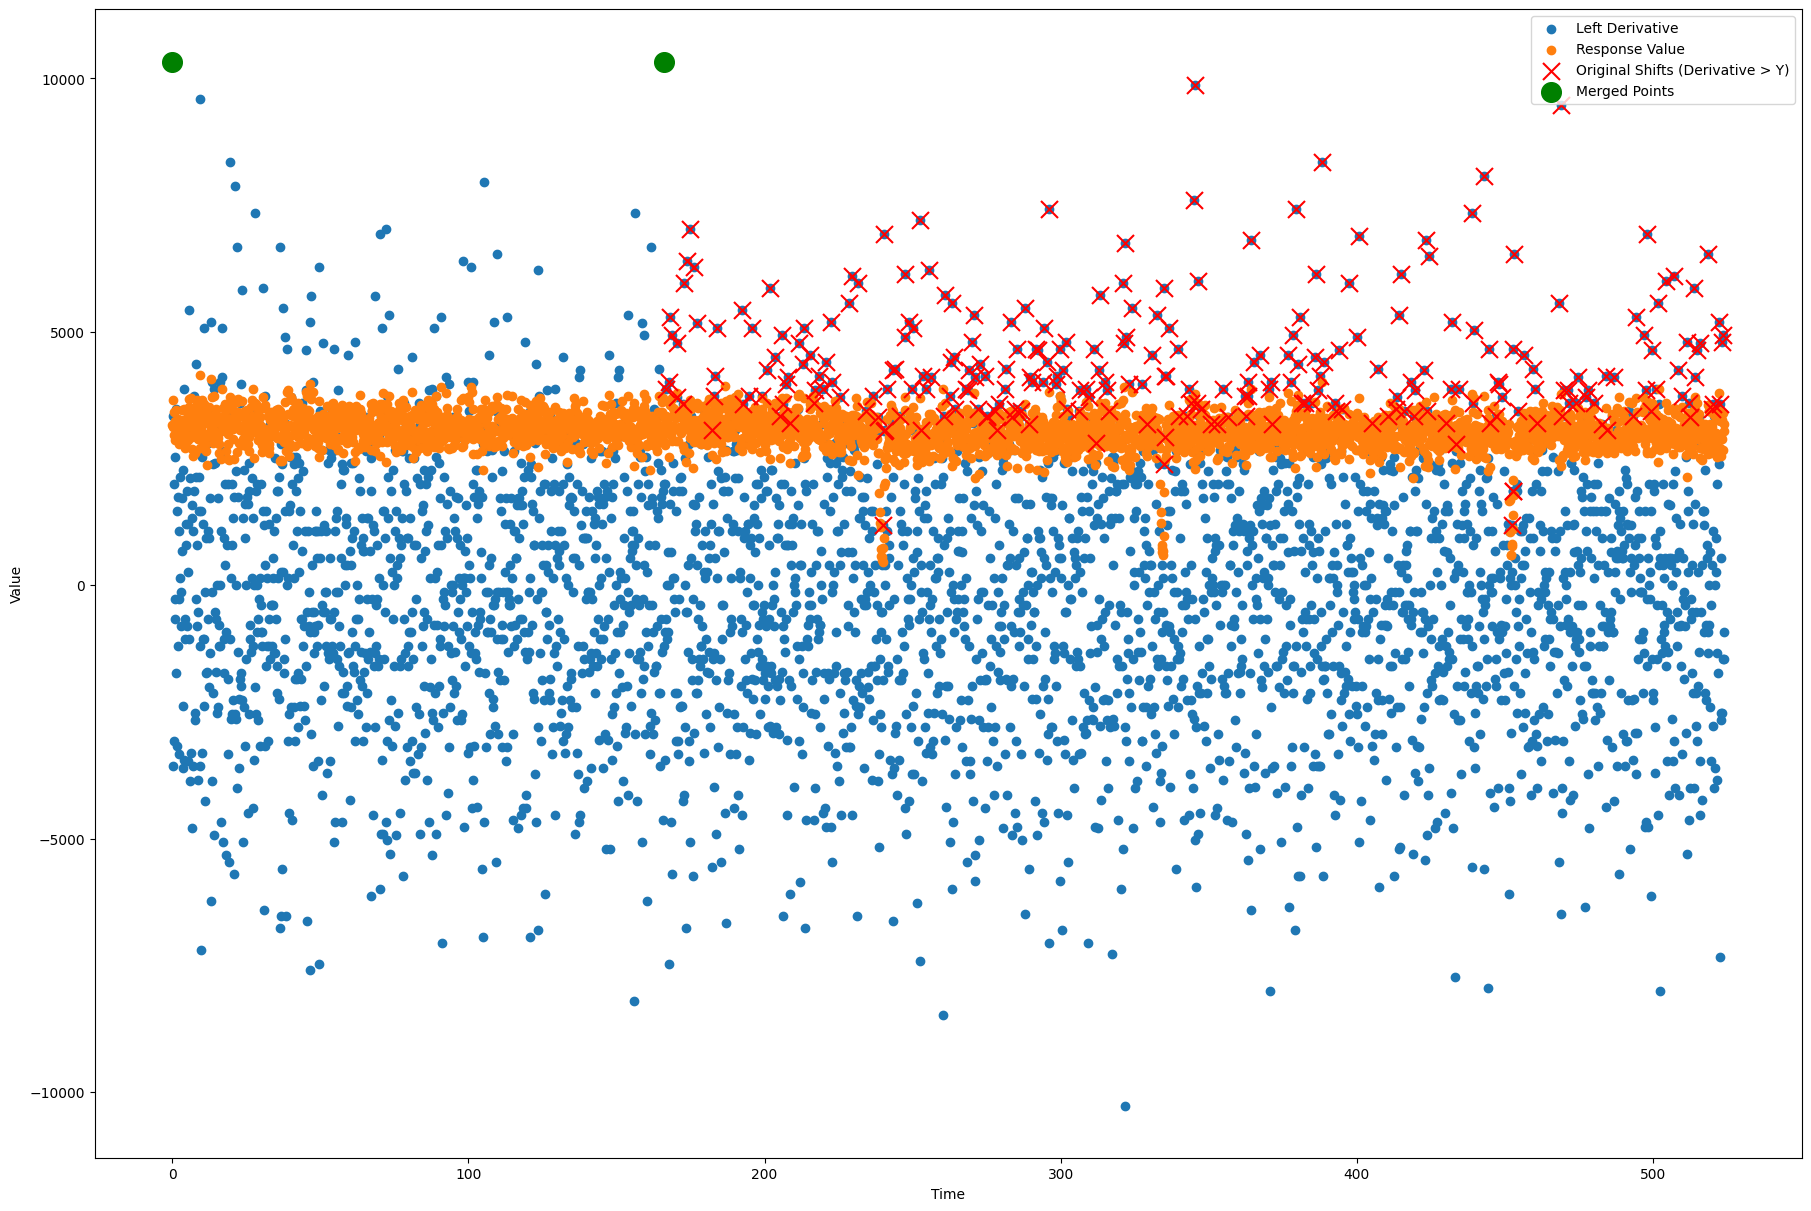

In [22]:
fig, ax1 = plt.subplots(figsize=(18, 12), layout='constrained')

# Plot original data and derivatives
ax1.scatter(left_derivatives_df_c.index, left_derivatives_df_c['Left_Derivative'], label='Left Derivative')
ax1.scatter(df['Time'], df[response], label='Response Value')

# Plot the original 'shifts' as red 'x' marks
ax1.scatter(shifts.index,
            left_derivatives_df_c.loc[shifts.index, 'Left_Derivative'],
            marker='x', color='red', s=150, zorder=4, label='Original Shifts (Derivative > Y)')


# Add the merged points to the plot as green circles
ax1.scatter(merged_points_list, [ax1.get_ylim()[1] * 0.95] * len(merged_points_list),
            marker='o', color='green', s=200, zorder=5, label='Merged Points') # Plot high up to be visible'

ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.legend()
plt.savefig(f'{figure_dir}/Regional-Final.png',bbox_inches='tight',dpi=300)
plt.show()


In [23]:
detected_intervals = get_detected_intervals(shifts_index=merged_points_list)
detected_intervals.append((detected_intervals[-1][1], df['Time'].max()))
detected_intervals
# detected_intervals

[(np.float64(0.0), np.float64(166.05125948716682)),
 (np.float64(166.05125948716682), np.float64(524.0))]

NameError: name 'df_c' is not defined

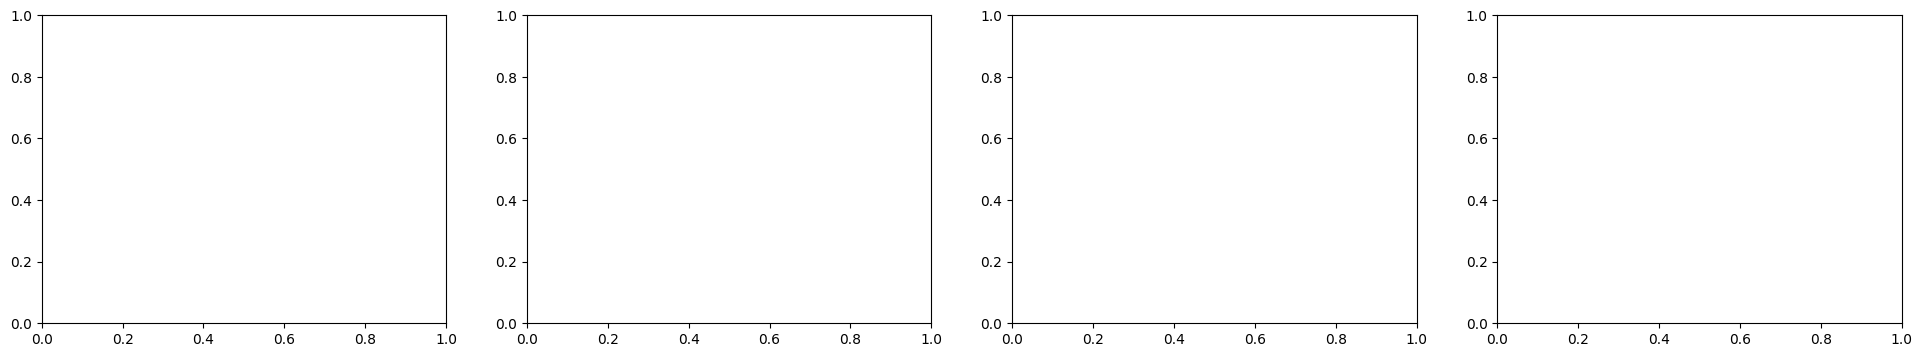

In [24]:
regional_means = []

num_regions = len(detected_intervals)
ncols = 4 # You can change the number of columns
nrows = (num_regions + ncols - 1) // ncols

offset = 15 # 15 seconds offset to 

final_df = pd.DataFrame()


fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24, 4 * nrows))
axes_flat = axes.flatten() # Flatten the 2D axes array for easier iteration
for i, (x0, x1) in enumerate(detected_intervals):
    # Get the current Axes object for this iteration from the flattened array
    if i < len(axes_flat):
        current_ax = axes_flat[i]
    else:
        # This case should ideally not happen if nrows is calculated correctly,
        # but provides a safeguard if more plots are attempted than subplots available.
        logging.warning(f" Not enough subplots for region {i+1}. Skipping plot.")
        continue
    

    # Call your outlier removal function for the current region
    original_region_data = get_region(df=df_c, t0=x0, tf=x1)
    Y_prime = remove_outliers_by_region(R=(x0 + offset, x1 - offset), response_column_name=response, Y=df_c)

    # logging.info(f'New Region {i+1}: ({val['Start'] + offset}, {val['End'] - offset})')

    # Plot the results on the current subplot
    if not Y_prime.empty:
        # Plot the data after outlier removal
        current_ax.plot(Y_prime['Time'], Y_prime[response], label='Outliers Removed', color='blue', alpha=0.8)
        
        # Plot original data for comparison (only within the current region)

        
        current_ax.plot(original_region_data['Time'], original_region_data[response],
                        '--', color='yellow', alpha=0.7, label='Original Data')
        
        region_mean = Y_prime[response].mean()
        original_mean = original_region_data[response].mean()
        
        current_ax.axhline(y=region_mean, color='#FF69B4', linestyle='-.', label=f'mean={region_mean}')
        current_ax.axhline(y=original_mean, color='red', linestyle='--', label=f'original mean={original_mean}')

        regional_means.append(region_mean)
        
        current_ax.legend(fontsize='small')
    else:
        current_ax.text(0.5, 0.5, 'No Data or Outliers Removed\nfor this Region',
                        horizontalalignment='center', verticalalignment='center',
                        transform=current_ax.transAxes, fontsize=10, color='red')
        continue

    # Set titles and labels for the current subplot
    current_ax.set_title(f'Region {i+1}: {x0} to {x1}')
    current_ax.set_xlabel('Time (s)')
    current_ax.set_ylabel(f'{response}')
    current_ax.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability

    final_df = pd.concat([final_df, Y_prime], ignore_index=True)



# This prevents empty plots from appearing if your `area_df` has fewer regions than the grid size
for j in range(num_regions, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.savefig(f'{figure_dir}/regions.png',
             bbox_inches='tight',
             dpi=300)
plt.tight_layout() # Automatically adjust subplot parameters for a tight layout
plt.show() # Display the plot
    
# plt.tight_layout()
# plt.show()

In [25]:
final_df = final_df.sort_index()
final_df

""


# Indicate the regions here

In [ ]:
# List of tuples indicating the x-axis, seperated by commas
# The same length as number of regions
regions = [1,2,5,10]



labels = np.array([regions])

[]

ValueError: x and y must be the same size

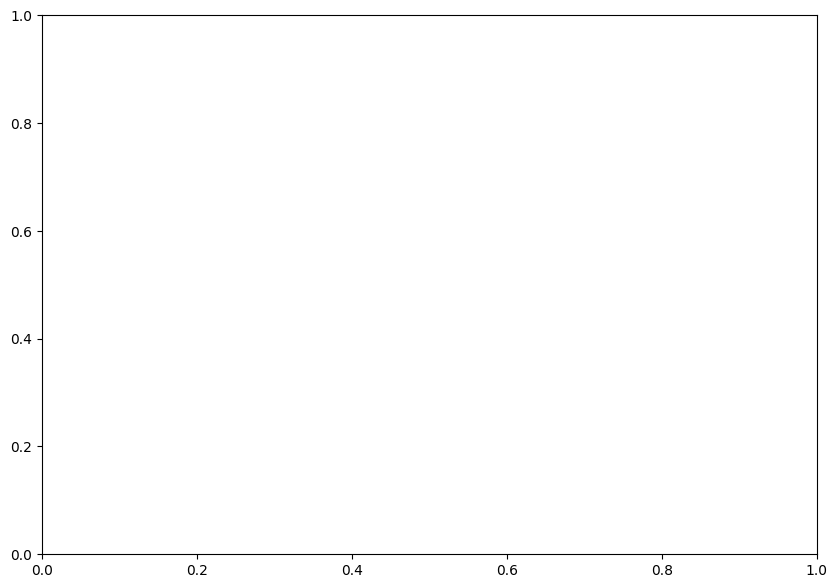

In [26]:
display(regional_means)
# Plot regional means
data = pd.DataFrame(regional_means, labels)

fig, ax1 = plt.subplots(figsize=(10, 7))

# Plot the bars
ax1.scatter(data.index, data.values)  # Convert index to string for proper label display
m,b = np.polyfit(labels, regional_means, 1)

model = LinearRegression()

X = labels.reshape(-1, 1)
y = np.array(regional_means)

model.fit(X,y)

r_squared = model.score(X,y)


# Find regression equation
if b >= 0:
    line_label = f'y = {m}x + {b}'
else:
    line_label = f'y = {m}x - {-b}' # Use -b to show a positive number after the minus sign

ax1.plot(labels, m*labels + b, color='red', label=f'{line_label}, r²={r_squared}')


plt.legend()

ax1.set_xlabel('Region')
ax1.set_ylabel(f'{response} (mean)')



plt.tight_layout()
plt.savefig(f'{figure_dir}/Regression-Plot.png', bbox_inches='tight',dpi=300)
plt.show()


$$ \textit{Opus ex amino, } \\ \text{Bhagawat Chapagain} $$